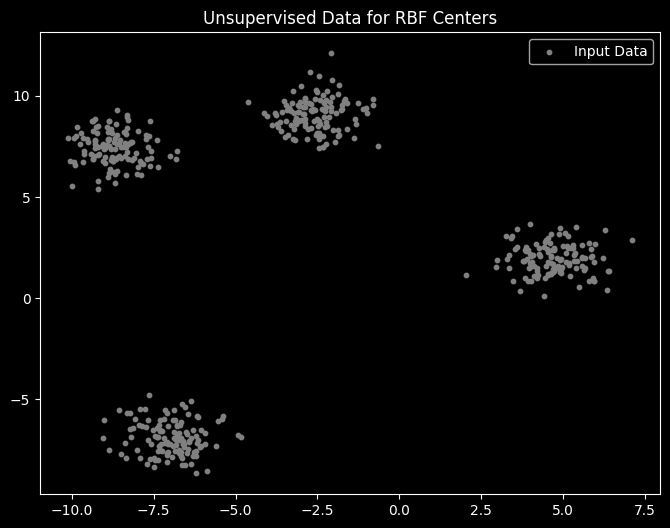

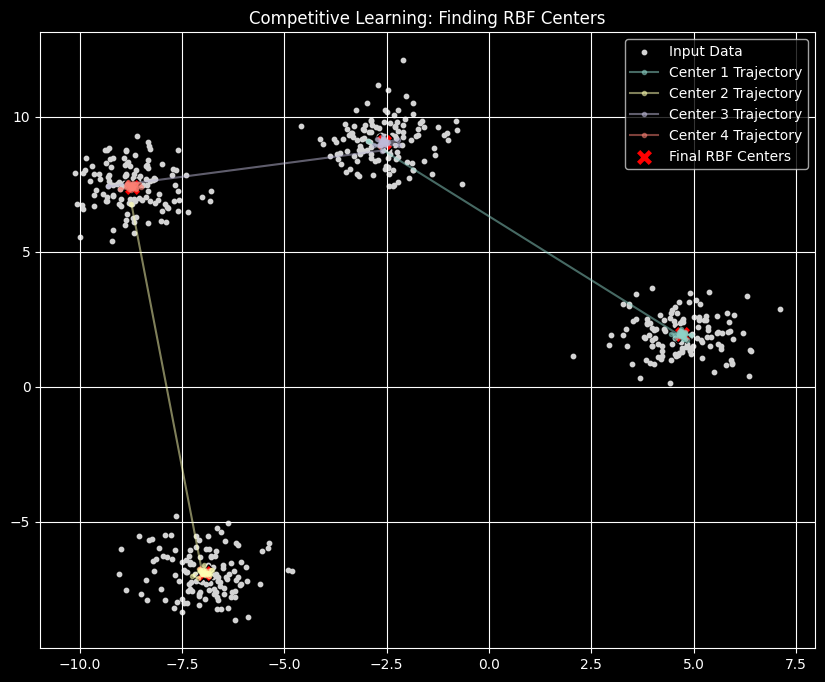

Sample point [0 8] activation for each center:
Neuron 1 (Center at [4.72 1.94]): Activation = 0.0000
Neuron 2 (Center at [-6.97 -6.91]): Activation = 0.0000
Neuron 3 (Center at [-2.58  9.08]): Activation = 0.1762
Neuron 4 (Center at [-8.71  7.42]): Activation = 0.0000


In [1]:
# Cell 1: Imports and Setup
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Set random seed for reproducibility
np.random.seed(42)

# Cell 2: Generate Synthetic Data
# We'll create a 2D dataset with 4 distinct clusters
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=0.8, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=10, color='gray', label='Input Data')
plt.title('Unsupervised Data for RBF Centers')
plt.legend()
plt.show()

# Cell 3: Competitive Learning Algorithm
def competitive_learning(X, num_centers, epochs=50, initial_lr=0.1):
    """
    Finds RBF centers using Winner-Takes-All competitive learning.
    """
    n_samples, n_features = X.shape
    
    # 1. Initialize centers randomly from the data distribution
    # (A common trick to avoid dead units is picking random data points)
    random_indices = np.random.choice(n_samples, num_centers, replace=False)
    centers = X[random_indices].copy()
    
    # Track center history for visualization
    history = [centers.copy()]
    
    for epoch in range(epochs):
        # Decay learning rate
        lr = initial_lr * (1.0 - epoch / epochs) 
        
        # Shuffle data each epoch
        np.random.shuffle(X)
        
        for x in X:
            # Step 1: Calculate distances from x to all centers
            distances = np.linalg.norm(centers - x, axis=1)
            
            # Step 2: Competition (Find the winner)
            winner_idx = np.argmin(distances)
            
            # Step 3: Update the winner
            centers[winner_idx] += lr * (x - centers[winner_idx])
            
        history.append(centers.copy())
        
    return centers, np.array(history)

# Cell 4: Train and Visualize
num_rbf_neurons = 4
final_centers, center_history = competitive_learning(X, num_centers=num_rbf_neurons, epochs=30)

# Plotting the results
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], s=10, color='lightgray', label='Input Data')

# Plot the trajectory of the centers
for k in range(num_rbf_neurons):
    traj = center_history[:, k, :]
    plt.plot(traj[:, 0], traj[:, 1], marker='.', linestyle='-', alpha=0.5, 
             label=f'Center {k+1} Trajectory')

# Plot final centers
plt.scatter(final_centers[:, 0], final_centers[:, 1], s=150, color='red', 
            marker='X', edgecolor='black', label='Final RBF Centers')

plt.title('Competitive Learning: Finding RBF Centers')
plt.legend()
plt.grid(True)
plt.show()

# Cell 5: (Bonus) Evaluating an RBF Output
# Once centers are found, this is how an RBF neuron evaluates a new point
def rbf_activation(x, center, sigma=1.0):
    distance_sq = np.linalg.norm(x - center)**2
    return np.exp(-distance_sq / (2 * sigma**2))

sample_point = np.array([0, 8])
print(f"Sample point {sample_point} activation for each center:")
for i, center in enumerate(final_centers):
    act = rbf_activation(sample_point, center, sigma=1.5)
    print(f"Neuron {i+1} (Center at {center.round(2)}): Activation = {act:.4f}")